# Experimental Design
_It is the process by which we carry out research in an objective & controlled fashion._
## Definitions
**Subjects**: (what we're experimenting on- could be people/ users/ students etc.) can be divided into 2 test groups:
- **Treatment group:** group to which one changes are given; the group to be studied

- **Control group:** not given any change (the placebo group) ; results already known for this group


In [1]:
import  pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
hw_main = pd.read_csv('./datasets/weightsheights.csv')
hw_main.head()

,Height(Inches),Weight(Pounds),Height in cm,Weight in kg,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,category
0,65.78331,112.9925,167.089517,51.252597,2.0,160,0.393701,170.0,160-170
1,71.51521,136.4873,181.648535,61.909672,NaN,180,NaN,190.0,180-190
2,69.39874,153.0269,176.272704,69.411917,NaN,180,NaN,190.0,180-190
3,68.21660,142.3354,173.270070,64.562328,NaN,170,NaN,180.0,170-180
4,67.78781,144.2971,172.180944,65.452141,NaN,170,NaN,180.0,170-180


In [3]:
# extracting only the heights column
heights = hw_main[['Height in cm']]
heights.head()

,Height in cm
0,167.089517
1,181.648535
2,176.272704
3,173.270070
4,172.180944


## Assigning subjects to groups

**Non-random assignment**
- Split the dataframe manually using `.iloc`<br>
    Example: splitting a dataframe with 1K rows into `iloc[0:050]` & `iloc[501:1000]`


In [4]:
nonrandom_g1 = heights.iloc[0:(len(heights)//2)]
nonrandom_g2 = heights.iloc[(len(heights)//2):]
compare_nr = pd.concat([nonrandom_g1['Height in cm'].describe(), nonrandom_g2['Height in cm'].describe()], axis=1)
print(compare_nr)

       Height in cm  Height in cm
count  12500.000000  12500.000000
mean     172.668017    172.736814
std        4.838883      4.821573
min      153.956048    153.106952
25%      169.357926    169.507805
50%      172.676676    172.754502
75%      175.915257    176.002468
max      190.888009    190.116103


>**Random assignment**
- Using `.sample()` method with no replacement

Definition :
>Randomization is **the process of assigning subjects to treatment groups using a random mechanism**, so that treatment assignment is independent of subjects' pre-existing characteristics.

Its purpose :
>Its primary purpose is to reduce systematic differences between treatment groups and prevent confounding, allowing differences in outcomes to be more credibly attributed to the treatment.

Since it makes treatment assignment independent of potential confounding variables, atleast in expectation that is why randomized controlled experiments are considered the strongest standard design for establishing causal effects.

**NOTE:** It does NOT guarantee identical groups.<br>
It only **guarantees a random assignment mechanism** and not perfect balance in every sample.

In [5]:
random_g1 = heights.sample(frac=0.5, replace=False, random_state=42)
# in Group-2 consider only unique rows not considered in Group-1 
random_g2 = heights.drop(random_g1.index)
compare_rd = pd.concat([random_g1['Height in cm'].describe(), random_g2['Height in cm'].describe()], axis=1)
print(compare_rd)

       Height in cm  Height in cm
count  12500.000000  12500.000000
mean     172.697820    172.707011
std        4.842663      4.818017
min      154.447665    153.106952
25%      169.447760    169.423268
50%      172.722129    172.698634
75%      175.946962    175.966939
max      190.792480    190.888009



### What happens if data is not randomized?
Randomization makes assignment independent of the characteristics of the participants, on average.

#### Randomization vs random sampling

**Random sampling-** Determines who enters your study (selection of subjects). Helps improve representativeness

**Random assignment (randomization)-** determines which treatment each subject receives. Helps improve causal inference & reduce confounding

_____

End result:
>**Without randomization** - _"The treatment group performed better."_<br>
This is an association.

>**With proper randomization** - _"The treatment caused the treatment group to perform better."_ <br>
This is a much more defensible causal claim, subject to the rest of the experiment being properly designed and analysed.


____
### Potential Issues with simple Randomization
_and how to tackle them_
#### Issues commonly faced
- Uneven group sizes after randomization - often seen in small population sizes
- Covariates - group imbalances due to another _outside_ variable that was earlier not factored into the experiment. These could cause a biased result , making it hard to see the effects from a treatment


### Blocking / Stratified randomization:
- Split into blocks and then assigns treatments randomly
- **Blocking is the broader experimental-design concept**: control a known source of variation by grouping similar experimental units and comparing treatments within each block.
- **Stratified randomization is specifically a randomization procedure**: divide participants into strata based on important characteristics and perform random assignment separately within each stratum.
- It divides experimental units into relatively homogeneous groups,**based on an important pre-treatment characteristic**, and then randomizes participants within each block.

>So, in many practical situations: Stratified randomization can be thought of as using blocking specifically during the randomization stage.

In [6]:
np.random.seed(42)
n = 200
example_df = pd.DataFrame({"engineer_id": range(n),"experience_years": np.random.normal(5, 5, n)})
print(example_df.head())
print(f"Dataframe shape={example_df.shape}\n")

# Random assignment
example_df["group"] = np.random.choice(["Control", "Treatment"], size=n)
print(example_df.head()) 

# Summarize after assigning
example_df.groupby("group")["experience_years"].agg(["count", "mean", "std"])

   engineer_id  experience_years
0            0          7.483571
1            1          4.308678
2            2          8.238443
3            3         12.615149
4            4          3.829233
Dataframe shape=(200, 2)

   engineer_id  experience_years      group
0            0          7.483571  Treatment
1            1          4.308678  Treatment
2            2          8.238443    Control
3            3         12.615149  Treatment
4            4          3.829233    Control


,count,mean,std
group,,,
Control,89,4.678711,4.156258
Treatment,111,4.890304,5.036058


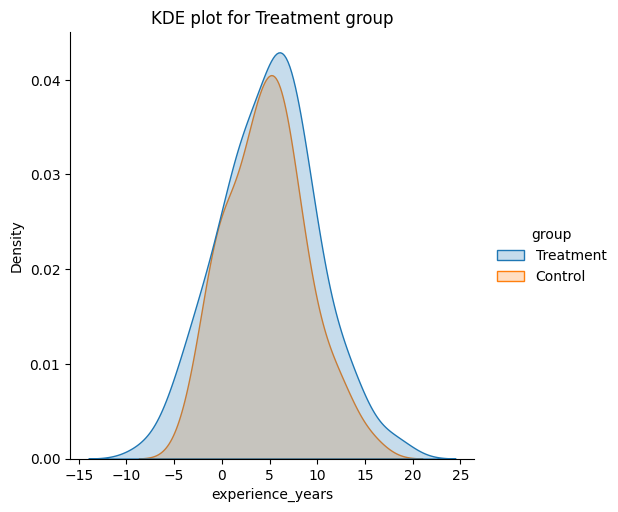

In [7]:
sns.displot(data=example_df, x='experience_years', hue='group', kind='kde', fill=True)
plt.title('KDE plot for Treatment group')
plt.show()

We implemented simple randomization above -- but the treatment group happens to have 0.3 years more experience.

If experience substantially affects productivity, **that imbalance can influence the measured treatment effect.**

>**Now implementing Blocking/ Stratified randomization to address the imbalace due to experience level:**

In [43]:
# example - to show difference in pd.cut & pd.qcut outputs
# 1. divide based on condition into equal widths & then placed data into the bins
categories_cut = pd.cut(example_df["experience_years"], bins=3, labels=["low","mid", "high"])
print(categories_cut.value_counts())
# 2. straight-up divided through the data so each bin has equal amounts of data
categories_qcut = pd.qcut(example_df["experience_years"], q=3, labels=["low", "mid", "high"])
print(categories_qcut.value_counts())


experience_years
mid     133
low      41
high     26
Name: count, dtype: int64
experience_years
low     67
high    67
mid     66
Name: count, dtype: int64


In [8]:
example_df1 = example_df.copy()
# create stratums/ groups based on experience level
example_df1["experience_level"] = pd.cut(example_df1["experience_years"],bins=[0, 3, 7, np.inf],labels=["Junior", "Mid", "Senior"])

# create & initialize a new column 'group' 
example_df1["group"] = None

# loops through each of the experience level
for level in example_df1["experience_level"].unique():
    # extract the indexes for particular level
    idx = example_df1.index[example_df1["experience_level"] == level]
    
    assignments = np.array(["Control", "Treatment"] * (len(idx) // 2 + 1))[:len(idx)]

    np.random.shuffle(assignments)

    example_df1.loc[idx, "group"] = assignments

example_df1.head()

# Checking the imbalance
example_df1.groupby("group")["experience_years"].agg(["count", "mean", "std"])

,count,mean,std
group,,,
Control,85,6.185199,3.635807
Treatment,83,6.060059,3.909278


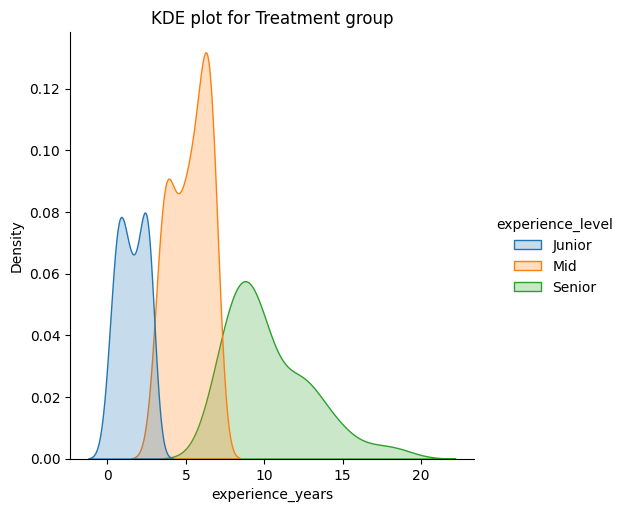

In [9]:
sns.displot(data=example_df1, x='experience_years', hue='experience_level', kind='kde', fill=True)
plt.title('KDE plot for Treatment group')
plt.show()

>By using Blocking randomization You should generally get much closer group means.

#### Confounding variable
The variable that might be causing the effect rather than the treatment applied.

____


In [10]:
pd.read_csv("./datasets/expd_datasets/hr_wellness.csv").head()

,Department,Wellness_Program_Status
0,Marketing,Enrolled
1,Sales,Enrolled
2,Marketing,Not Enrolled
3,Marketing,Not Enrolled
4,Sales,Enrolled


#### Limitations of Block Randomization
- There's always a **credible possibility of chance imbalance** whenever a simple block randomization is implemented.<br>
The result could be, for example, that the Treatment group accidentally gets more senior engineers than the Control group. 

- Also , in small sample size, randomization does not balance important characteristics well

### Stratified randomization:
- Stratify (divide) into groups & then apply randomization **within each group**. 
- This method eliminates the chance imbalance that could occur within each group after sample has been divided.
- Also helps  eliminate/minimize the effects of any covariates on the treatment groups 

In [11]:
mrktg_df = pd.read_feather("./datasets/expd_datasets/marketing_data.feather")
print(mrktg_df.head())

print(f"Dataframe shape = {mrktg_df.shape}\n")

print(mrktg_df.info())

  Messaging_Style Time_of_Day  Click_Through_Rate  Conversions
0          Casual     Morning            0.640465          500
1          Formal     Evening            0.698533          598
2          Casual     Morning            0.257834          234
3          Casual     Evening            0.922971          602
4          Casual     Morning            0.476893          314
Dataframe shape = (950, 4)

<class 'pandas.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Messaging_Style     950 non-null    str    
 1   Time_of_Day         950 non-null    str    
 2   Click_Through_Rate  950 non-null    float64
 3   Conversions         950 non-null    int64  
dtypes: float64(1), int64(1), str(2)
memory usage: 41.9 KB
None


In [12]:
# looking into messaging style & time of day categories
mrktg_df[["Time_of_Day","Messaging_Style"]].value_counts()

Time_of_Day  Messaging_Style
Morning      Formal             250
             Casual             239
Evening      Casual             231
             Formal             230
Name: count, dtype: int64

>Observation: Its clear that both -- time of day and messaging style can affect the conversion & click_throughs

- So, there is a possibilty of chance imbalance occuring if normal block randomization is implemented

In [13]:
# Example-1
# creating a copy df
mrktg_df2 = mrktg_df.copy()

# simple randomization
mrktg_df2["group_simple"] = np.random.choice(["T","C"], size=len(mrktg_df2))

print("----Checking with pd.crosstab:----")
print(pd.crosstab(mrktg_df["Messaging_Style"], mrktg_df2["group_simple"]))
print("\n")
print(pd.crosstab(mrktg_df["Time_of_Day"], mrktg_df2["group_simple"]))

----Checking with pd.crosstab:----
group_simple       C    T
Messaging_Style          
Casual           226  244
Formal           235  245


group_simple    C    T
Time_of_Day           
Evening       225  236
Morning       236  253


>Thus we observe that simple randomization does not explicitly guarantee balance across important characteristics.

In this case, we know that `Messaging_Style` &  `Time_of_Day` affect the conversion rate. So any randomization that does not take these covariates in account would have a possiblity of chance imbalance.

**The Solution:**<br>
Now, we first divide observations into strata based on important pre-treatment characteristics, then randomize within each stratum.

Since there are 2 potentially important variables (Messaging_Style, Time_of_Day) we can combine them.

In [14]:
# combininig the two covariates in a new column
mrktg_df2["strata"] = (mrktg_df2["Messaging_Style"] + "_" + mrktg_df2["Time_of_Day"])

print(mrktg_df2.head())
print("\n")
print(mrktg_df2["strata"].value_counts())

  Messaging_Style Time_of_Day  Click_Through_Rate  Conversions group_simple  \
0          Casual     Morning            0.640465          500            T   
1          Formal     Evening            0.698533          598            C   
2          Casual     Morning            0.257834          234            T   
3          Casual     Evening            0.922971          602            T   
4          Casual     Morning            0.476893          314            T   

           strata  
0  Casual_Morning  
1  Formal_Evening  
2  Casual_Morning  
3  Casual_Evening  
4  Casual_Morning  


strata
Formal_Morning    250
Casual_Morning    239
Casual_Evening    231
Formal_Evening    230
Name: count, dtype: int64


In [15]:
# initiate new column
mrktg_df2["group_stratfd"] = None

# iterate each categorical formed >> get series of indexes matching current categorical
# shuffle treatment groups >> assign values to the new column matching current categorical
for stratum in mrktg_df2["strata"].unique():
    idx = mrktg_df2.index[mrktg_df2["strata"] == stratum]

    assignments = np.random.choice(["T", "C"], size=len(idx))

    mrktg_df2.loc[idx, "group_stratfd"] = assignments

mrktg_df2.head()

,Messaging_Style,Time_of_Day,Click_Through_Rate,Conversions,group_simple,strata,group_stratfd
0,Casual,Morning,0.640465,500,T,Casual_Morning,C
1,Formal,Evening,0.698533,598,C,Formal_Evening,T
2,Casual,Morning,0.257834,234,T,Casual_Morning,C
3,Casual,Evening,0.922971,602,T,Casual_Evening,C
4,Casual,Morning,0.476893,314,T,Casual_Morning,C


Comparing the two randomizations

In [16]:
print(pd.crosstab(mrktg_df["Messaging_Style"], mrktg_df2["group_simple"]))

group_simple       C    T
Messaging_Style          
Casual           226  244
Formal           235  245


In [17]:
pd.crosstab(mrktg_df2["strata"], mrktg_df2["group_stratfd"])

group_stratfd,C,T
strata,,
Casual_Evening,121,110
Casual_Morning,111,128
Formal_Evening,110,120
Formal_Morning,127,123


So what we've achieved is:
- Simple randomization: randomize entire population together.
- Stratified randomization: divide by important characteristics first, then randomize separately within each group.

>**Observation:** 
>- Simple randomization allows important covariates to become imbalanced purely by chance.
>- Stratified randomization ensures that randomization occurs separately within each predefined subgroup, substantially improving balance across important covariates.


In [18]:
import pandas as pd
import numpy as np

np.random.seed(42)
df = pd.DataFrame({
    'id': range(1, 21),
    'age_group': np.random.choice(['young', 'old'], size=20)  # covariate
})
df

,id,age_group
0,1,young
1,2,old
2,3,young
3,4,young
4,5,young
5,6,old
6,7,young
7,8,young
8,9,young
9,10,old


In [19]:
def assign_treatment(group):
    n = len(group)
    labels = ['treatment', 'control'] * (n // 2) + ['treatment'] * (n % 2)
    group['group'] = np.random.permutation(labels)
    return group

In [20]:
df['group'] = None
for _, idx in df.groupby("age_group").groups.items():
    df.loc[idx, "group"] = assign_treatment(df.loc[idx])

In [21]:
df.groupby(['age_group', 'group']).size()

age_group  group    
old        control      3
           treatment    4
young      control      6
           treatment    7
dtype: int64

In [22]:
# An even simpler implementation
for stratum in df['age_group'].unique():
    idx = df.index[df["age_group"] == stratum]
    n = len(idx)
    labels = ["T", "C"] * (n // 2) + ["T"] * (n % 2)  # or random tie-break as shown earlier
    assignments = np.random.permutation(labels)
    df.loc[idx, "group_stratfd"] = assignments

df

,id,age_group,group,group_stratfd
0,1,young,treatment,C
1,2,old,treatment,T
2,3,young,control,T
3,4,young,treatment,T
4,5,young,treatment,C
5,6,old,treatment,T
6,7,young,treatment,T
7,8,young,control,T
8,9,young,control,T
9,10,old,treatment,C


In [23]:
for stratum in df['age_group'].unique():
    idx1 = df.index[df["age_group"] == stratum]
    labels = ["T", "C"] * (n // 2) + ["T"] * (n % 2)  # or random tie-break as shown earlier
    assignments = np.random.permutation(labels)
    print(assignments)


['C' 'T' 'T' 'C' 'T' 'T' 'C']
['C' 'T' 'T' 'T' 'C' 'T' 'C']


____
## Criteria for parameteric Hypothesis tests
_A recap_
### 1. Visual Tests

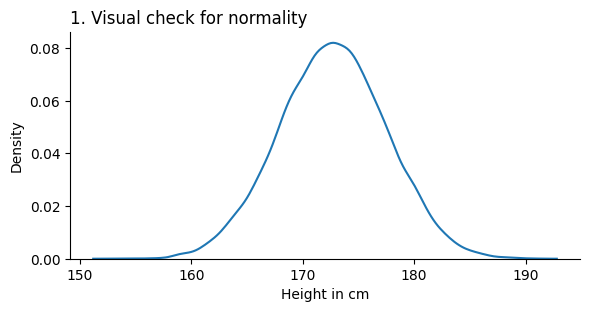

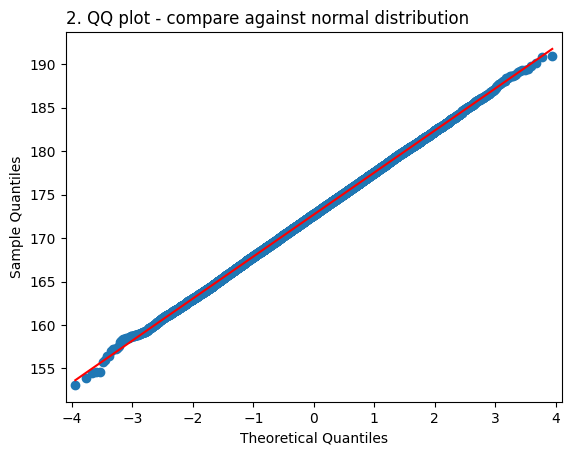

In [24]:
# 1. checking for normality
sns.displot(heights["Height in cm"], kind="kde", aspect=2, height=3)
plt.title("1. Visual check for normality",loc="left")
plt.show()

# 2. QQ plot to compare data to a particular dostribution
from statsmodels.graphics.gofplots import qqplot
from scipy.stats.distributions import norm
qqplot(heights["Height in cm"], line='s', dist=norm)
plt.title("2. QQ plot - compare against normal distribution",loc="left")
plt.show()


### 2. Numerical Tests
Operate on the assumption $H_0$ : Data is drawn from a normal distribution.

#### Shapiro-Wilk test

In [25]:
# 1.Shapiro Wilk test -- consider alpha = 0.05
from scipy.stats import shapiro
stats,pval = shapiro(heights["Height in cm"])
print(f"Test stat: {round(stats,4)} , p-value: {round(pval, 4)}")

Test stat: 0.9999 , p-value: 0.6627


c:\Users\abhijeet.bhambere\Desktop\Resources\DC-ADS\dcvenv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 25000.
  res = hypotest_fun_out(*samples, **kwds)


>Since $\text{p-value}$ (0.6637) > $\alpha$ (0.05), we reject fail to reject the null hypothesis

Meaning the Heights distribution is very likely to be normal.

#### Anderson-Darling test
Provides a range of critical values to assess normality at different significance levels. The function returns an object containing three main components:
- `statistic:` The calculated Anderson-Darling test metric for your dataset.
- `critical_values:` An array of threshold values.
- `significance_level:` An array of percentages (usually [15. , 10. ,  5. ,  2.5,  1. ]) corresponding to each critical value.

1. Match your chosen significance level (commonly 5%) to its corresponding critical value:
2. **If Statistic > Critical Value:** Reject the null hypothesis ($H_0$). Your data does not follow the tested distribution.
3. **If Statistic ≤ Critical Value:** Fail to reject the null hypothesis ($H_0$). Your data safely assumes the tested distribution.

In [26]:
# 2. Anderson-Darling test
from scipy.stats import anderson
result = anderson(x=heights["Height in cm"], dist='norm')

print(f"Result= {result.statistic.round(4)}")
print(f"Significance levels: {result.significance_level}")
print(f"Critical values: {result.critical_values}")

Result= 0.2418
Significance levels: [15.  10.   5.   2.5  1. ]
Critical values: [0.576 0.656 0.787 0.918 1.092]


As observed above, the statistic is less than critical valus across all significance levels. 
>This means we fail to reject the $H_0$ & its safe to assume that **the data is very likely to be normally distributed**


This is a really useful distinction for your stats/interview preparation:

Shapiro–Wilk → usually **p-value based**: `p < α → reject H₀`

Anderson–Darling → SciPy's anderson() **output is critical-value based**: `statistic > critical value → reject H₀`

### EXAMPLE:
#### PART-1
50 chickens, divided into four groups, each fed a different diet. Weight measurements were taken every second day for 20 days.

>Q: Assess normality which will determine the suitability of parametric statistical tests, beginning with a visual examination of the data distribution.

In [27]:
cw_df = pd.read_csv("./datasets/expd_datasets/chick_weight.csv")

print(cw_df.info())
print(cw_df.head())

<class 'pandas.DataFrame'>
RangeIndex: 578 entries, 0 to 577
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   weight  578 non-null    int64
 1   Time    578 non-null    int64
 2   Chick   578 non-null    int64
 3   Diet    578 non-null    int64
dtypes: int64(4)
memory usage: 18.2 KB
None
   weight  Time  Chick  Diet
0      42     0      1     1
1      51     2      1     1
2      59     4      1     1
3      64     6      1     1
4      76     8      1     1


Q: Plot the distribution of the chickens' weight using the kernel density estimation (KDE) to visualize normality.

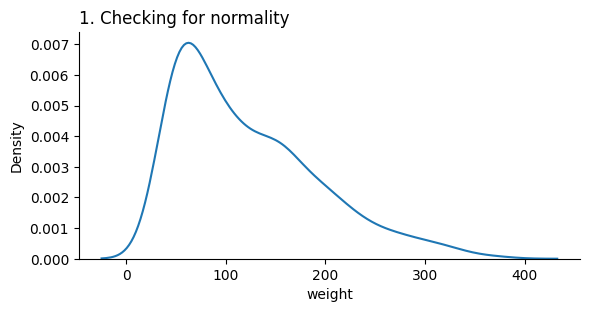

In [28]:
sns.displot(data=cw_df["weight"], kind="kde", aspect=2, height=3)
plt.title("1. Checking for normality", loc="left")
plt.show()

Q: Create a qq plot with a standard line of the chickens' weight to assess normality visually.


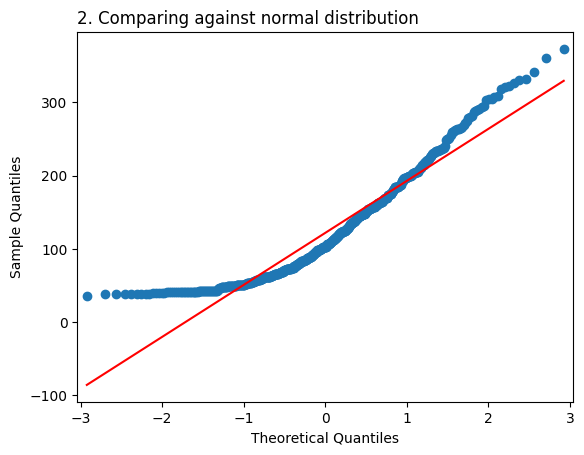

In [29]:
qqplot(data= cw_df["weight"], line="s",)
plt.title("2. Comparing against normal distribution", loc="left")
plt.show()

>Above plots indicate that data distribution is not purely normal for the given population.

Q: Subset chicken_data for a 'Time' of 2, and plot the KDE of 'weight' from subset_data to check if data is normal across time.

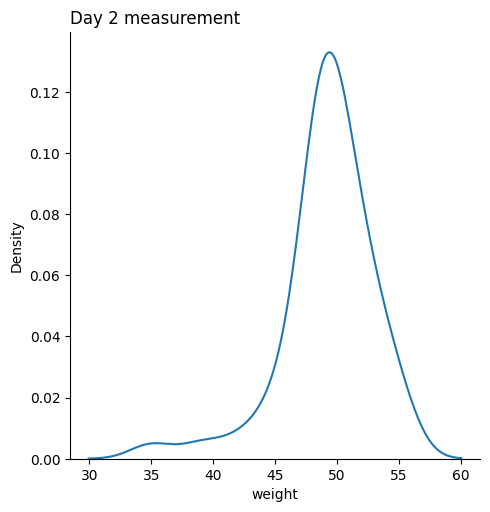

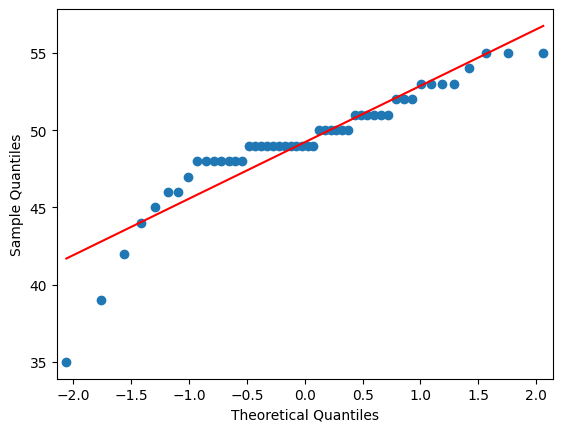

In [30]:
subset_data = cw_df[cw_df['Time'] == 2]
sns.displot(data=subset_data, x='weight', kind="kde")
plt.title("Day 2 measurement", loc="left")
plt.show()

qqplot(data=subset_data["weight"], line="s")
plt.show()

>Visual inspections of the data indicate it may not be a normal dataset overall, **but that the initial time point may be**.

Now we use numerical tests to probe this subset further & check if data is normally distributed for parametric tests

#### PART-2
Q: Run a Shapiro-Wilk test of normality on the 'weight' column and print the test statistic and p-value.

In [31]:
test_stat, p_val = shapiro(cw_df["weight"])
print(f"Test stat = {test_stat} ; p-value = {p_val}")


Test stat = 0.9086615388045551 ; p-value = 3.873675666382505e-18


Q: Run an Anderson-Darling test for normality and print out the test statistic, significance levels, and critical values from the returned object.

In [32]:
test_result = anderson(x=cw_df["weight"], dist="norm")
print(f"Test stat = {test_result.statistic}")
print(f"Significance values = {test_result.significance_level}")
print(f"Critical values= {test_result.critical_values}")

Test stat = 14.686760276613654
Significance values = [15.  10.   5.   2.5  1. ]
Critical values= [0.572 0.652 0.782 0.912 1.085]


>In both above methods, we find the p-value is $< \alpha$ (considered as 0.05 standard) for Shapiro-Wilk test, whereas in Anderson-Darling test the statistic is greater than all critical levels across all ,<br>
So we can reject the Null hypothesis ($H_0$ , that data is normally distributed) & conclude that data is NOT normally distributed.

_____
## Factorial Design


In [33]:
mrktg_df

,Messaging_Style,Time_of_Day,Click_Through_Rate,Conversions
0,Casual,Morning,0.640465,500
1,Formal,Evening,0.698533,598
2,Casual,Morning,0.257834,234
3,Casual,Evening,0.922971,602
4,Casual,Morning,0.476893,314
...,...,...,...,...
945,Casual,Morning,0.759764,579
946,Casual,Evening,0.654387,65
947,Formal,Morning,0.269222,292
948,Formal,Evening,0.419846,25


In [34]:
# Convert the dataframe to a CSV format string and print it
# print(plant_growth_data.to_csv(index=False))
# 